## PDE Solved by This QPINN

The QPINN in this script solves the following second-order ODE:

$$
\frac{d^2\phi}{dx^2} - x(x-1) = 0, \qquad x \in [0,1].
$$

with boundary conditions:

$$
\phi(0) = 0, \qquad \phi(1) = 0.
$$


## Import packages

In [1]:
import torch
import torch.nn as nn
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

## Loss Function Definition

The total loss is composed of a PDE residual loss and a boundary condition loss:

$$
\mathcal{L} = \mathcal{L}_{\mathrm{PDE}} + 0.1\,\mathcal{L}_{\mathrm{BC}}.
$$

### PDE Residual Loss

The PDE being solved is:

$$
\phi''(x) - x(x-1) = 0 .
$$

For training points $ x_i \in [0,1] $, the residual is:

$$
r(x_i) = \phi''(x_i) - x_i(x_i - 1).
$$

The PDE loss is the mean squared residual:

$$
\mathcal{L}_{\mathrm{PDE}}
= \frac{1}{N}\sum_{i=1}^{N} \left( \phi''(x_i) - x_i(x_i - 1) \right)^2 .
$$

### Boundary Condition Loss

The problem enforces the boundary conditions:

$$
\phi(0) = 0, \qquad \phi(1) = 0.
$$

Thus, the boundary loss is:

$$
\mathcal{L}_{\mathrm{BC}} = \phi(0)^2 + \phi(1)^2 .
$$


Starting training...
Iteration 1/200, Total Loss: 49.344288, PDE Loss: 49.144485, BC Loss: 1.998029
Iteration 2/200, Total Loss: 49.305084, PDE Loss: 49.105515, BC Loss: 1.995698
Iteration 3/200, Total Loss: 49.265241, PDE Loss: 49.065994, BC Loss: 1.992472
Iteration 4/200, Total Loss: 49.224657, PDE Loss: 49.025822, BC Loss: 1.988350
Iteration 5/200, Total Loss: 49.183178, PDE Loss: 48.984844, BC Loss: 1.983336
Iteration 6/200, Total Loss: 49.140645, PDE Loss: 48.942902, BC Loss: 1.977433
Iteration 7/200, Total Loss: 49.096798, PDE Loss: 48.899734, BC Loss: 1.970640
Iteration 8/200, Total Loss: 49.051383, PDE Loss: 48.855087, BC Loss: 1.962962
Iteration 9/200, Total Loss: 49.004003, PDE Loss: 48.808563, BC Loss: 1.954397
Iteration 10/200, Total Loss: 48.954299, PDE Loss: 48.759804, BC Loss: 1.944949
Iteration 11/200, Total Loss: 48.901725, PDE Loss: 48.708263, BC Loss: 1.934613
Iteration 12/200, Total Loss: 48.845762, PDE Loss: 48.653423, BC Loss: 1.923391
Iteration 13/200, Total Loss

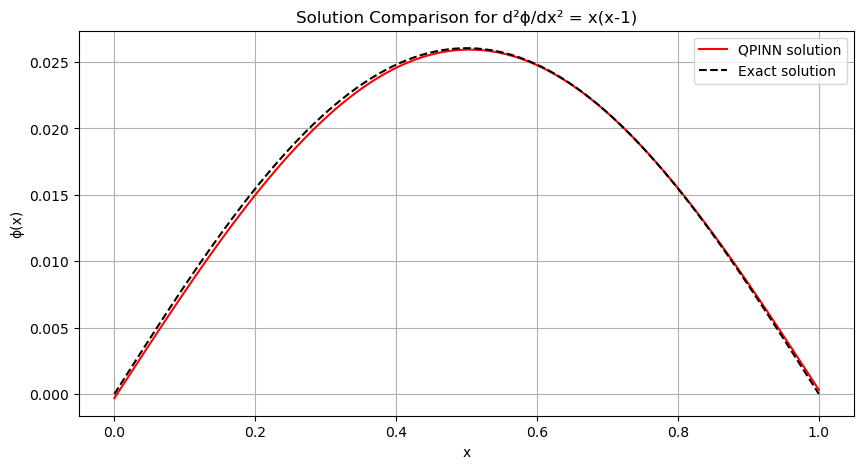

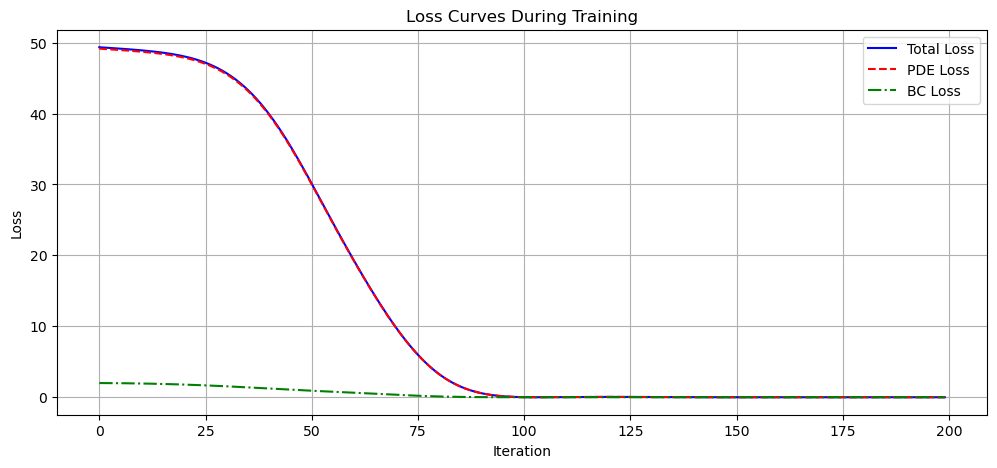

In [10]:
# ----------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------
num_qubits = 1               # Number of qubits in the quantum circuit
num_layers = 3               # Number of variational layers
learning_rate = 0.005         # Learning rate for the optimizer
num_iterations = 200        # Number of training iterations
n_points = 100                # Number of training points in [0,1]

# ----------------------------------------------------------
# Create PennyLane device
# ----------------------------------------------------------
# Specify diff_method="backprop" to use PyTorch backpropagation
dev = qml.device("default.qubit", wires=num_qubits)

# ----------------------------------------------------------
# Quantum Circuit Definition
# ----------------------------------------------------------
@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_model(params, x):
    """
    This QNode encodes the input x using a single RX rotation
    and applies several variational layers defined by params.
    The output is the expectation value of PauliZ on the qubit.
    
    Note:
    Instead of using AngleEmbedding (which may trigger an implicit numpy conversion),
    we encode x with an RY gate that remains differentiable.
    """
    # Data encoding with RY gate directly
    theta = x*np.pi
    qml.RY(theta, wires=0)

    # Variational layers: each layer is a Rot gate (3 parameters per layer)
    idx = 0
    for i in range(num_layers):
        qml.Rot(params[idx], params[idx+1], params[idx+2], wires=0)
        idx += 3

    # Measurement: return expectation value of PauliZ on qubit 0
    return qml.expval(qml.PauliZ(0))

# ----------------------------------------------------------
# Define a PyTorch Module wrapping the QNode
# ----------------------------------------------------------
class QPINN(nn.Module):
    def __init__(self, num_layers):
        super(QPINN, self).__init__()
        # We have 3 parameters per layer for the Rot gates
        self.num_params = 3 * num_layers
        # Initialize parameters with a small random initialization
        init_params = 0.01 * torch.randn(self.num_params)
        self.params = nn.Parameter(init_params)

    def forward(self, x):
        """
        Forward pass of the QPINN.
        x: Tensor of shape [batch_size]. The QNode is applied for each element.
        """
        # Ensure x is a 1D tensor
        x = x.view(-1)
        outputs = []
        for xi in x:
            # Pass xi directly as a tensor (remains differentiable)
            outputs.append(quantum_model(self.params, xi))
        return torch.stack(outputs)

# ----------------------------------------------------------
# Create the model instance
# ----------------------------------------------------------
model = QPINN(num_layers)

# ----------------------------------------------------------
# Physics-Informed Loss Construction
# ----------------------------------------------------------
def compute_pde_residual(phi_pred, x):
    """
    Computes the PDE residual for d^2 phi/dx^2 - x*(x-1)=0.
    Uses PyTorch autograd to compute first and second derivatives.
    """
    # First derivative dphi/dx
    dphi_dx = torch.autograd.grad(
        phi_pred, x,
        grad_outputs=torch.ones_like(phi_pred),
        create_graph=True
    )[0]
    # Second derivative d^2phi/dx^2
    d2phi_dx2 = torch.autograd.grad(
        dphi_dx, x,
        grad_outputs=torch.ones_like(dphi_dx),
        create_graph=True
    )[0]

    # PDE residual = d^2phi/dx^2 - x*(x-1)
    residual = d2phi_dx2 - x * (x - 1)
    return residual

def loss_function(x):
    """
    Computes the total loss as the sum of the PDE residual loss and
    the boundary condition (BC) losses.
    """
    # Enable gradient tracking for x (for second derivative calculation)
    x.requires_grad_(True)
    phi_pred = model(x)  # Predicted phi(x) from the QPINN

    # PDE residual loss: mean squared error of the residual
    residual = compute_pde_residual(phi_pred, x)
    pde_loss = torch.mean(residual**2)

    # Boundary conditions: phi(0)=0 and phi(1)=0 enforced by penalty terms
    bc0 = model(torch.tensor([0.0], dtype=x.dtype))
    bc1 = model(torch.tensor([1.0], dtype=x.dtype))
    bc_loss = bc0.pow(2).mean() + bc1.pow(2).mean()

    # Total loss is the sum of PDE residual loss and boundary condition loss
    total_loss = pde_loss + bc_loss * 0.1
    return total_loss, pde_loss, bc_loss

# ----------------------------------------------------------
# Training the Model
# ----------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Create training points in the domain [0,1]
x_train = torch.linspace(0, 1, n_points, dtype=torch.float32)

# Lists to store loss values over iterations for plotting
total_loss_list = []
pde_loss_list = []
bc_loss_list = []

print("Starting training...")
for i in range(num_iterations):
    optimizer.zero_grad()
    total_loss_value, pde_loss_value, bc_loss_value = loss_function(x_train)
    total_loss_value.backward()
    optimizer.step()

    total_loss_list.append(total_loss_value.item())
    pde_loss_list.append(pde_loss_value.item())
    bc_loss_list.append(bc_loss_value.item())

    if (i + 1) % 1 == 0:
        print(f"Iteration {i+1}/{num_iterations}, Total Loss: {total_loss_value.item():.6f}, "
              f"PDE Loss: {pde_loss_value.item():.6f}, BC Loss: {bc_loss_value.item():.6f}")

print("Training finished.")

# ----------------------------------------------------------
# Evaluate the solution and compare with the exact solution
# ----------------------------------------------------------
# Create evaluation grid (no gradient needed for evaluation)
x_eval = torch.linspace(0, 1, 100, dtype=torch.float32)
with torch.no_grad():
    phi_pred_eval = model(x_eval)

def exact_solution(x):
    """Analytical solution: 1/12*(x - 2*x**3 + x**4)"""
    return (1.0/12.0) * (x - 2.0 * x**3 + x**4)

phi_exact_eval = exact_solution(x_eval)

# ----------------------------------------------------------
# Plot the learned solution vs. the exact solution
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(x_eval.cpu().numpy(), phi_pred_eval.cpu().numpy(), 'r-', label='QPINN solution')
plt.plot(x_eval.cpu().numpy(), phi_exact_eval.cpu().numpy(), 'k--', label='Exact solution')
plt.title("Solution Comparison for d²ϕ/dx² = x(x-1)")
plt.xlabel("x")
plt.ylabel("ϕ(x)")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------------------------------
# Plot the loss curves over training iterations
# ----------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(total_loss_list, 'b-', label='Total Loss')
plt.plot(pde_loss_list, 'r--', label='PDE Loss')
plt.plot(bc_loss_list, 'g-.', label='BC Loss')
plt.title("Loss Curves During Training")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Print circuit

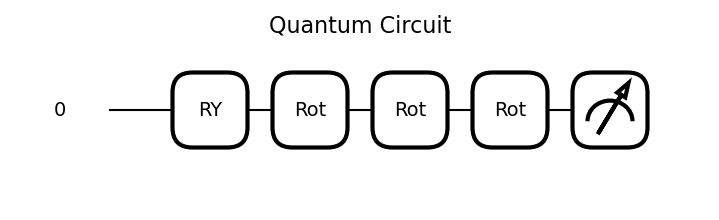

In [7]:
# ----------------------------------------------------------
# Draw the quantum circuit using Matplotlib
# ----------------------------------------------------------
def plot_circuit():
    x_example = torch.tensor(0, dtype=torch.float32)
    with torch.no_grad():
        params_example = model.params.detach().clone()

    fig, ax = qml.draw_mpl(quantum_model, expansion_strategy="device")(params_example, x_example)
    fig.suptitle(f"Quantum Circuit", fontsize=16)
    plt.show()

plot_circuit()
